# Week 5 — Quantum Machine Learning: Encoding, Classifiers, and Barren Plateaus

**Quantum Artificial Intelligence**

---

We now assemble everything into a genuine machine-learning model that runs on a quantum circuit. A
**variational quantum classifier (VQC)** has three parts that mirror a classical neural network: a
**feature map** that encodes classical data into a quantum state, a **trainable ansatz** (the
variational circuit of Week 4), and a **measurement** that produces a prediction. We train it by the
parameter-shift gradients we derived, on a real classification task.

We then confront the central obstacle of quantum machine learning — **barren plateaus**, where
gradients vanish exponentially with system size — and see why circuit design, not just optimization,
determines whether a quantum model can be trained at all.

Roadmap:

1. **Data encoding** (feature maps): getting classical data into Hilbert space.
2. A complete **variational quantum classifier**, trained end to end with PennyLane.
3. **Decision boundaries** and the role of encoding in expressivity.
4. **Barren plateaus**: the vanishing-gradient problem unique to quantum models.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)


## 1. Encoding classical data into quantum states

A quantum model can only process data that has been mapped into a quantum state. This **feature map**
(or data-encoding circuit) is the quantum analogue of the input layer, and its choice profoundly
affects what the model can learn — encoding is where much of a quantum model's power, or weakness,
lives.

The most common scheme is **angle encoding**: each feature $x_i$ becomes a rotation angle. For a
2-feature point $x=(x_1,x_2)$ on two qubits,

$$
|\phi(x)\rangle = \big(R_y(x_1)\otimes R_y(x_2)\big)\,|00\rangle .
$$

A richer choice repeats or entangles the encoding so the resulting state depends on the data
nonlinearly — this is what lets a quantum feature map act like a nonlinear kernel (Week 6). The key
theoretical fact: a data-encoding circuit makes the measured expectation a **truncated Fourier series**
in the input features, and re-uploading the data multiple times increases the accessible frequencies,
hence the expressivity. We visualize a simple angle encoding's effect on the output expectation.


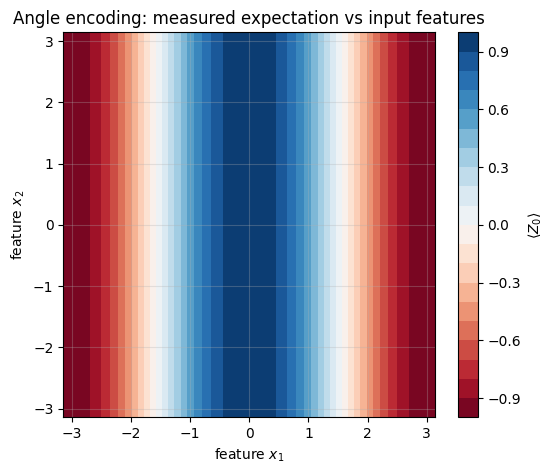

The encoding induces a smooth, periodic feature landscape the classifier reshapes.


In [2]:
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def encoding_demo(x):
    qml.RY(x[0], wires=0)
    qml.RY(x[1], wires=1)
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

# Show the output expectation as a function of the two input features
g = np.linspace(-np.pi, np.pi, 60)
G1, G2 = np.meshgrid(g, g)
Zout = np.array([[encoding_demo([a, b]) for a in g] for b in g])

plt.figure(figsize=(6, 5))
plt.contourf(G1, G2, Zout, levels=20, cmap="RdBu")
plt.colorbar(label=r"$\langle Z_0\rangle$")
plt.xlabel("feature $x_1$"); plt.ylabel("feature $x_2$")
plt.title("Angle encoding: measured expectation vs input features")
plt.show()
print("The encoding induces a smooth, periodic feature landscape the classifier reshapes.")


The encoded expectation varies smoothly and periodically with the inputs — the feature map has lifted
the 2-D data into a structured landscape on the Bloch sphere. The classifier's job is to add trainable
gates that warp this landscape until the two classes are separated. Periodicity is a fingerprint of
quantum encodings: outputs are Fourier series in the data.

## 2. A variational quantum classifier

We build a full VQC and train it to separate two classes. The circuit is: **encode** the data point,
apply a **trainable ansatz** with several layers of rotations and entanglers, and **measure** $\langle
Z_0\rangle$, whose sign gives the predicted label. We train by minimizing a square loss with PennyLane's
Adam optimizer (gradients via parameter-shift). The dataset is the classic two-moons, a nonlinearly
separable problem.


In [3]:
def make_moons(n, noise=0.15, seed=0):
    r = np.random.default_rng(seed)
    n1 = n//2; n2 = n - n1
    t1 = np.pi * r.random(n1)
    x1 = np.stack([np.cos(t1), np.sin(t1)], 1)
    t2 = np.pi * r.random(n2)
    x2 = np.stack([1 - np.cos(t2), 1 - np.sin(t2) - 0.5], 1)
    Xd = np.concatenate([x1, x2]) + noise*r.standard_normal((n, 2))
    yd = np.array([-1]*n1 + [1]*n2)
    # scale features into a rotation-friendly range
    Xd = (Xd - Xd.mean(0)) / Xd.std(0) * (np.pi/2)
    return Xd.astype(float), yd

X, y = make_moons(120, seed=1)

n_layers = 3
@qml.qnode(dev)
def classifier(weights, x):
    # encode
    qml.RY(x[0], wires=0); qml.RY(x[1], wires=1)
    # trainable layers
    for L in range(len(weights)):
        qml.RY(weights[L][0], wires=0); qml.RY(weights[L][1], wires=1)
        qml.RZ(weights[L][2], wires=0); qml.RZ(weights[L][3], wires=1)
        qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def predict(weights, X):
    return np.array([classifier(weights, x) for x in X])

def loss(weights, X, y):
    preds = qml.math.stack([classifier(weights, x) for x in X])
    return qml.math.mean((preds - y)**2)

weights = pnp.array(0.1*rng.standard_normal((n_layers, 4)), requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)
loss_hist, acc_hist = [], []
for step in range(60):
    weights, l = opt.step_and_cost(lambda w: loss(w, X, y), weights)
    if step % 5 == 0 or step == 59:
        preds = np.sign(predict(weights, X))
        acc = np.mean(preds == y)
        loss_hist.append((step, float(l))); acc_hist.append((step, acc))
        print(f"step {step:3d}  loss {float(l):.4f}  train acc {acc:.3f}")


step   0  loss 1.4683  train acc 0.542


step   5  loss 1.0113  train acc 0.683


step  10  loss 0.7562  train acc 0.725


step  15  loss 0.7463  train acc 0.750


step  20  loss 0.7105  train acc 0.767


...

step  40  loss 0.3995  train acc 0.900


step  45  loss 0.3934  train acc 0.908


step  50  loss 0.3876  train acc 0.900


step  55  loss 0.3784  train acc 0.908


step  59  loss 0.3750  train acc 0.908


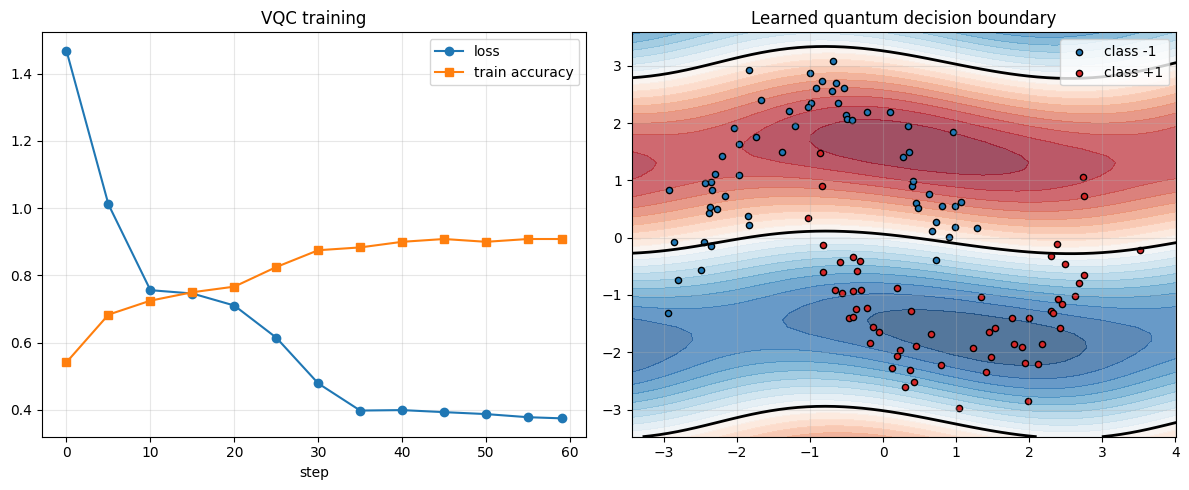

In [4]:
# Plot training curves and the learned decision boundary
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
steps_l, vals_l = zip(*loss_hist); steps_a, vals_a = zip(*acc_hist)
ax1.plot(steps_l, vals_l, "o-", label="loss")
ax1.plot(steps_a, vals_a, "s-", label="train accuracy")
ax1.set_xlabel("step"); ax1.set_title("VQC training"); ax1.legend()

gx = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 60)
gy = np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 60)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX.ravel(), GY.ravel()], 1)
Zgrid = predict(weights, grid).reshape(GX.shape)
ax2.contourf(GX, GY, Zgrid, levels=20, cmap="RdBu", alpha=0.7)
ax2.contour(GX, GY, Zgrid, levels=[0], colors="k", linewidths=2)
ax2.scatter(X[y==-1,0], X[y==-1,1], c="C0", s=20, edgecolors="k", label="class -1")
ax2.scatter(X[y==1,0], X[y==1,1], c="C3", s=20, edgecolors="k", label="class +1")
ax2.set_title("Learned quantum decision boundary"); ax2.legend()
plt.tight_layout(); plt.show()


The variational quantum classifier learns a curved decision boundary that separates the two moons,
reaching high training accuracy — a working quantum machine-learning model trained entirely with the
parameter-shift gradients we derived in Week 4. The nonlinearity comes from the data encoding and the
entangling layers; without entanglement the model would be limited to product states and far weaker.

## 3. Why encoding matters

The expressivity of a VQC is set largely by its feature map. A useful diagnostic: a single-qubit angle
encoding produces an expectation that is a low-order Fourier series in the data, so it can only fit
slowly varying functions. **Data re-uploading** — interleaving encoding and trainable layers so the
data enters multiple times — enriches the frequency spectrum and lets the same number of qubits fit
more complex functions. We demonstrate the difference by fitting a target function with one versus
three data re-uploads.


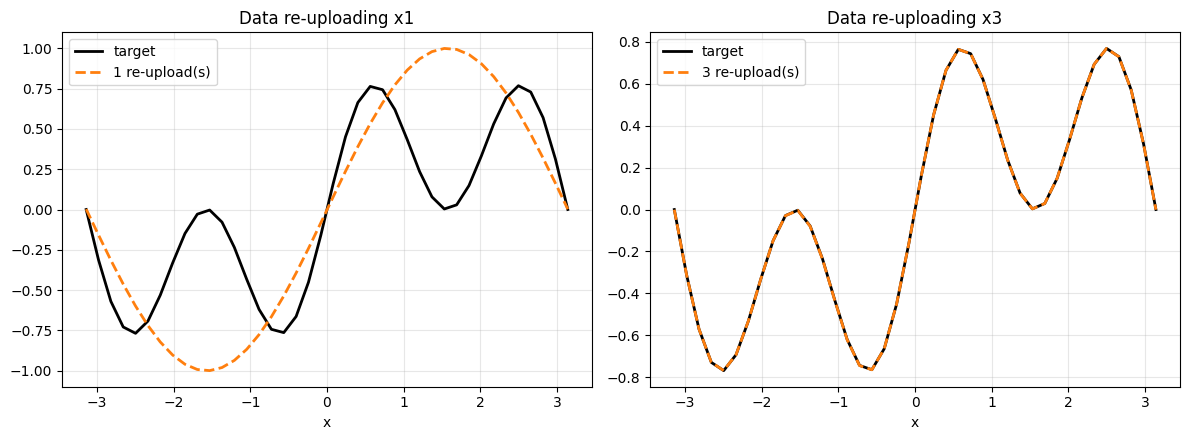

More re-uploads => access to higher frequencies => fits the multi-frequency target better.


In [5]:
def fit_target(n_reupload, steps=120):
    devx = qml.device("default.qubit", wires=1)
    @qml.qnode(devx)
    def model(params, x):
        for r in range(n_reupload):
            qml.RY(x, wires=0)                 # re-upload the data
            qml.RY(params[r, 0], wires=0)
            qml.RZ(params[r, 1], wires=0)
        return qml.expval(qml.PauliZ(0))
    target = lambda x: np.sin(2*x) * np.cos(x)     # a multi-frequency target
    xs = np.linspace(-np.pi, np.pi, 40)
    ys = target(xs)
    params = pnp.array(0.1*rng.standard_normal((n_reupload, 2)), requires_grad=True)
    opt = qml.AdamOptimizer(0.1)
    def cost(p): return qml.math.mean((qml.math.stack([model(p, x) for x in xs]) - ys)**2)
    for _ in range(steps):
        params, _ = opt.step_and_cost(cost, params)
    pred = np.array([model(params, x) for x in xs])
    return xs, ys, pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, nr in zip(axes, [1, 3]):
    xs, ys, pred = fit_target(nr)
    ax.plot(xs, ys, "k-", lw=2, label="target")
    ax.plot(xs, pred, "C1--", lw=2, label=f"{nr} re-upload(s)")
    ax.set_title(f"Data re-uploading x{nr}"); ax.legend(); ax.set_xlabel("x")
plt.tight_layout(); plt.show()
print("More re-uploads => access to higher frequencies => fits the multi-frequency target better.")


With a single data upload the model can only manage a crude fit; three re-uploads give it the higher
frequencies needed to track the oscillating target. This is the quantum analogue of adding capacity —
and it shows that in quantum machine learning, *how* you encode data is as important as the trainable
circuit. This Fourier-series view (Schuld et al., 2021) is one of the clearest theoretical handles we
have on quantum model expressivity.

## 4. Barren plateaus

Quantum machine learning has a notorious failure mode with no classical analogue: **barren plateaus**.
For many random, deep, highly-entangling ansätze, the gradient of the cost **vanishes exponentially**
with the number of qubits — the optimization landscape becomes an almost flat plateau, and training
stalls because there is no gradient signal to follow. We demonstrate the effect by measuring the
variance of a cost gradient as the number of qubits grows.


2 qubits: Var(gradient) = 1.637e-01
3 qubits: Var(gradient) = 1.670e-01
4 qubits: Var(gradient) = 8.151e-02
5 qubits: Var(gradient) = 4.571e-02
6 qubits: Var(gradient) = 1.562e-02


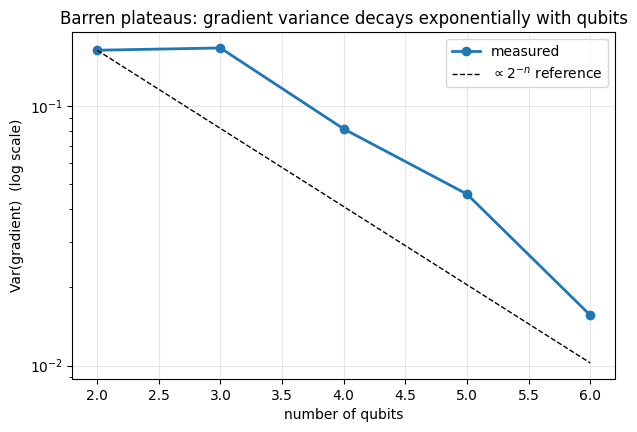


The exponential decay means deep random circuits become untrainable at scale.


In [6]:
def gradient_variance(n_qubits, n_layers=None, n_samples=50):
    # Deep random hardware-efficient circuit. Depth grows with width, which is the
    # regime where barren plateaus appear: gradient variance ~ 1/2^n.
    if n_layers is None:
        n_layers = 3 * n_qubits          # scale depth with width
    devb = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(devb)
    def rand_circuit(params):
        for L in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[L, q], wires=q)
            for q in range(n_qubits):
                qml.CZ(wires=[q, (q+1) % n_qubits])   # entangle in a ring
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))
    gradfn = qml.grad(rand_circuit)
    grads = []
    for _ in range(n_samples):
        p = pnp.array(rng.uniform(0, 2*np.pi, (n_layers, n_qubits)), requires_grad=True)
        grads.append(np.array(gradfn(p))[0, 0])      # one fixed component
    return np.var(grads)

qubit_counts = [2, 3, 4, 5, 6]
variances = [gradient_variance(n) for n in qubit_counts]
for n, v in zip(qubit_counts, variances):
    print(f"{n} qubits: Var(gradient) = {v:.3e}")

plt.figure()
plt.semilogy(qubit_counts, variances, "o-", lw=2, label="measured")
ref = variances[0] * (0.5 ** (np.array(qubit_counts) - qubit_counts[0]))
plt.semilogy(qubit_counts, ref, "k--", lw=1, label=r"$\propto 2^{-n}$ reference")
plt.xlabel("number of qubits"); plt.ylabel("Var(gradient)  (log scale)")
plt.title("Barren plateaus: gradient variance decays exponentially with qubits")
plt.legend(); plt.show()
print("\nThe exponential decay means deep random circuits become untrainable at scale.")


The gradient variance falls off exponentially as qubits are added — the signature of a barren
plateau. This is a fundamental obstacle: naively scaling up a quantum model makes it *harder*, not
easier, to train. Mitigations are an active research area: structured (problem-informed) ansätze,
careful initialization, local cost functions, and layerwise training. The lesson for a practitioner is
that quantum model design is inseparable from trainability — a theme that distinguishes QML sharply
from classical deep learning.

## 5. Summary

- A **variational quantum classifier** combines a data-encoding **feature map**, a trainable **ansatz**,
  and a **measurement**; we trained one to separate the two-moons dataset with a nonlinear quantum
  decision boundary.
- **Data encoding** determines expressivity: the measured output is a Fourier series in the inputs, and
  **data re-uploading** adds frequencies, improving the fit to complex functions.
- **Barren plateaus** — exponentially vanishing gradients in deep random circuits — are a distinctive
  trainability obstacle in QML, demanding structured ansätze and careful design.

In Week 6 we take a complementary, often more robust route to quantum machine learning — **quantum
kernel methods** — and a capstone that compares quantum and classical models head to head.


## 6. Exercises

**Exercise 1 (encoding comparison).** Replace angle encoding with amplitude encoding (load a normalized
2-vector directly as amplitudes) and compare classifier accuracy on the two-moons data.

**Exercise 2 (depth vs accuracy).** Sweep `n_layers` from 1 to 6 in the VQC and plot test accuracy.
Where does added depth stop helping, and can you see early signs of trainability trouble?

**Exercise 3 (re-uploading classifier).** Build a single-qubit data-re-uploading *classifier* (Pérez-
Salinas et al.) and show one qubit with enough re-uploads can separate the two moons.

**Exercise 4 (plateau mitigation).** For the barren-plateau experiment, replace the random
initialization with small angles near zero (identity-block initialization) and show the gradient
variance is restored at the start of training.


In [7]:
# Scratch space for the exercises.
